# Zomato Restaurant Analysis - Delhi NCR
> Overview
This project performs exploratory data analysis on a Zomato restaurant dataset 
containing information about restaurants in Delhi NCR. The analysis covers 
locality trends, cuisine patterns, pricing, ratings and hidden gems.

### Tools Used
- Python (Pandas, Matplotlib, Seaborn)
- Dataset: Kaggle - Zomato Delhi NCR Restaurants


### Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


### Loading .csv file of Zomato using pandas

In [4]:
df= pd.read_csv('DelhiNCR Restaurants.csv')

### Data Cleaning
### check the number of rows and columns

In [5]:
print(df.shape)

(1965, 15)


### check the datatype

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1965 entries, 0 to 1964
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Restaurant_Name        1965 non-null   str    
 1   Category               1965 non-null   str    
 2   Pricing_for_2          1965 non-null   int64  
 3   Locality               1965 non-null   str    
 4   Dining_Rating          1965 non-null   float64
 5   Dining_Review_Count    1965 non-null   int64  
 6   Delivery_Rating        1563 non-null   float64
 7   Delivery_Rating_Count  1965 non-null   int64  
 8   Website                1965 non-null   str    
 9   Address                1965 non-null   str    
 10  Phone_No               1965 non-null   str    
 11  Latitude               1965 non-null   float64
 12  Longitude              1965 non-null   float64
 13  Known_For2             1560 non-null   str    
 14  Known_For22            1124 non-null   str    
dtypes: float64(4), 

### check the first 10 rows

In [6]:
print(df.head(10))

                 Restaurant_Name  \
0                       Rustom's   
1                      Cafe Lota   
2         Dum-Pukht - ITC Maurya   
3                    Burma Burma   
4                  The Big Chill   
5                  Carnatic Cafe   
6  Cocktails & Dreams, Speakeasy   
7              Natural Ice Cream   
8   Kuremal Mohan Lal Kulfi Wale   
9                     Juggernaut   

                                            Category  Pricing_for_2  \
0  Parsi, Street Food, North Indian, Desserts, Be...           2100   
1        Cafe, South Indian, North Indian, Beverages           1200   
2                    Mughlai, North Indian, Desserts           5000   
3        Asian, Burmese, Bubble Tea, Desserts, Salad           1600   
4                     Continental, American, Italian           1500   
5                                       South Indian            600   
6                       Nepalese, Tibetan, Beverages           2500   
7                                Ic

### check the summary statistics 

In [7]:
print(df.describe())

       Pricing_for_2  Dining_Rating  Dining_Review_Count  Delivery_Rating  \
count    1965.000000    1965.000000          1965.000000      1563.000000   
mean     1090.687023       4.140000           721.954198         3.964299   
std       934.481617       0.202147           932.618839         0.242305   
min       100.000000       3.900000             3.000000         2.800000   
25%       500.000000       4.000000           244.000000         3.800000   
50%       700.000000       4.100000           433.000000         4.000000   
75%      1500.000000       4.300000           842.000000         4.100000   
max      8000.000000       4.900000         10100.000000         4.500000   

       Delivery_Rating_Count     Latitude    Longitude  
count            1965.000000  1965.000000  1965.000000  
mean             3029.550636    28.549542    77.161570  
std              6529.839896     0.784241     1.685399  
min                 0.000000    -5.975200     2.650463  
25%                34


### check the last 5 rows

In [8]:
print(df.tail(5))

       Restaurant_Name                                           Category  \
1960    Bablu Chic-Inn          Mughlai, North Indian, Chinese, Fast Food   
1961         Kovilakam                                       South Indian   
1962  Krips Restaurant                     North Indian, Chinese, Mughlai   
1963          Cafe 147  Cafe, North Indian, Chinese, Kashmiri, Rolls, ...   
1964          Pizzasia                        Pizza, Fast Food, Beverages   

      Pricing_for_2                                     Locality  \
1960            500               Ashok Vihar Phase 3, New Delhi   
1961            350                    Dilshad Garden, New Delhi   
1962            900   Basant Lok Market, Vasant Vihar, New Delhi   
1963            800                      Sainik Farms, New Delhi   
1964            500                   Gaur City 2, Greater Noida   

      Dining_Rating  Dining_Review_Count  Delivery_Rating  \
1960            3.9                  183              4.1   
1961  


### clean column names

In [9]:
df.columns= df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns)


Index(['restaurant_name', 'category', 'pricing_for_2', 'locality',
       'dining_rating', 'dining_review_count', 'delivery_rating',
       'delivery_rating_count', 'website', 'address', 'phone_no', 'latitude',
       'longitude', 'known_for2', 'known_for22'],
      dtype='str')


### check for null values

In [10]:
print(df.isnull().sum())

restaurant_name            0
category                   0
pricing_for_2              0
locality                   0
dining_rating              0
dining_review_count        0
delivery_rating          402
delivery_rating_count      0
website                    0
address                    0
phone_no                   0
latitude                   0
longitude                  0
known_for2               405
known_for22              841
dtype: int64



### check percentage of null values

In [11]:
print(df.isnull().sum()/ len(df)*100)

restaurant_name           0.000000
category                  0.000000
pricing_for_2             0.000000
locality                  0.000000
dining_rating             0.000000
dining_review_count       0.000000
delivery_rating          20.458015
delivery_rating_count     0.000000
website                   0.000000
address                   0.000000
phone_no                  0.000000
latitude                  0.000000
longitude                 0.000000
known_for2               20.610687
known_for22              42.798982
dtype: float64


### check duplicates

In [12]:

print(df.duplicated().sum())

0


### null handling

In [13]:
df['known_for2']= df['known_for2'].fillna('Not Specified')
df['known_for22']=df['known_for22'].fillna('Not Specified')
df['delivery_rating']= df['delivery_rating'].fillna(0)
print(df.isnull().sum())

restaurant_name          0
category                 0
pricing_for_2            0
locality                 0
dining_rating            0
dining_review_count      0
delivery_rating          0
delivery_rating_count    0
website                  0
address                  0
phone_no                 0
latitude                 0
longitude                0
known_for2               0
known_for22              0
dtype: int64



### clean text

In [16]:
df['locality']= df['locality'].str.strip().str.lower()
df['known_for2']= df['known_for2'].str.strip().str.lower()
df['known_for22']= df['known_for22'].str.strip().str.lower()

### download data

In [14]:
df.to_csv('zomato_cleaned.csv', index=False)
print("saved sucessfully!")

saved sucessfully!


### Exploratory Data Analysis
In this section we explore the cleaned Zomato dataset to uncover insights 
about restaurant trends, ratings, pricing and locality patterns across Delhi NCR.

### Loading clean dataset

In [15]:
df= pd.read_csv('zomato_cleaned.csv')

### Most rewiewed restaurant per locality

In [16]:
most_review_restaurant= df.groupby('locality')['dining_review_count'].idxmax()
result= df.loc[most_review_restaurant, ['locality', 'restaurant_name', 'dining_review_count']].head(10)
result = result.sort_values('dining_review_count', ascending=False)
print(result) 

                                         locality      restaurant_name  \
48                            Aerocity, New Delhi   Plum By Bent Chair   
334            3C's Mall, Lajpat Nagar, New Delhi      Jungle Jamboree   
826                        Amar Colony, New Delhi    The Colony Bistro   
555            32nd Avenue, NH8, Gurgaon, Gurgaon         CAD Tech Bar   
673                            Adchini, New Delhi  TC Bar & Restaurant   
890    Aditya City Centre, Indirapuram, Ghaziabad     Cinnamon Kitchen   
952                          Alaknanda, New Delhi         Al Qureshi's   
885      Aggarwal City Mall, Pitampura, New Delhi          Burger King   
744                        Alpha 2, Greater Noida               Elborz   
1722                   Aloft, Aerocity, New Delhi                 Nook   

      dining_review_count  
48                   2402  
334                  1381  
826                  1080  
555                  1070  
673                   978  
890              

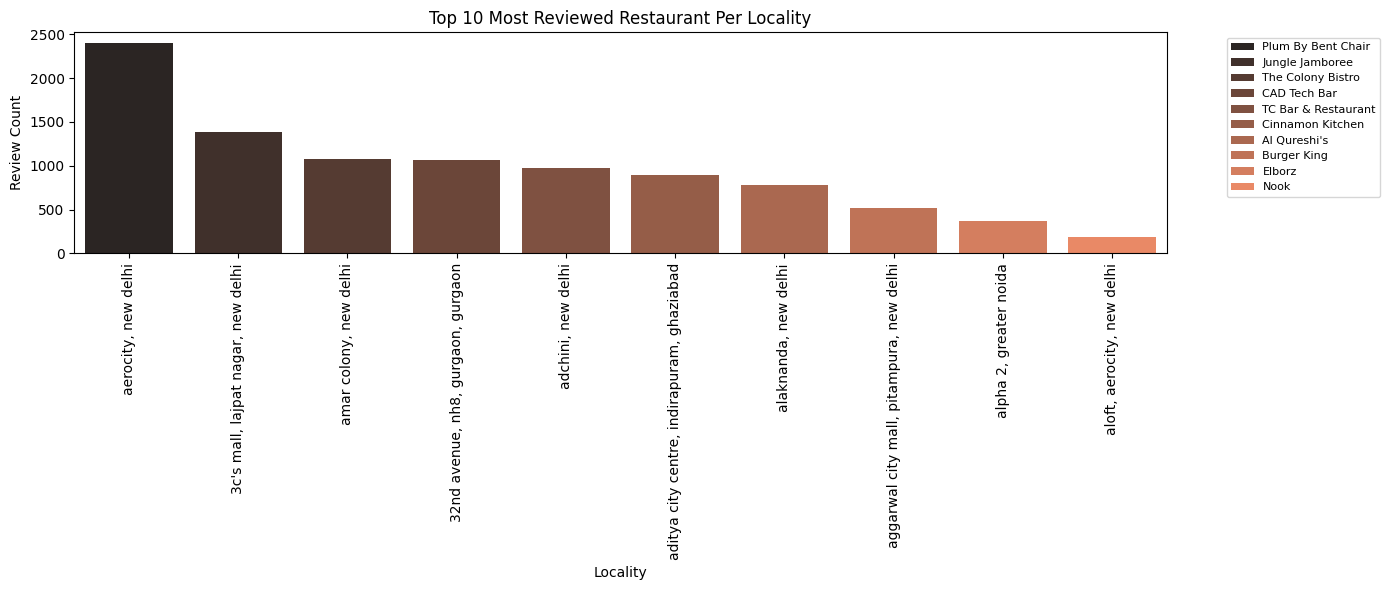

In [27]:
plt.figure(figsize=(14, 6))
sns.barplot(data=result, x='locality', y='dining_review_count', 
            hue='restaurant_name', color='coral')
plt.title('Top 10 Most Reviewed Restaurant Per Locality')
plt.xlabel('Locality')
plt.ylabel('Review Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Plum by Bent Chair located in Aerocity, New Delhi is the most reviewed restaurant in Delhi NCR

### Rating distribution per locality

In [21]:
top_locality= df['locality'].value_counts().head(15).index
df_filtered= df[df['locality'].isin(top_locality)]

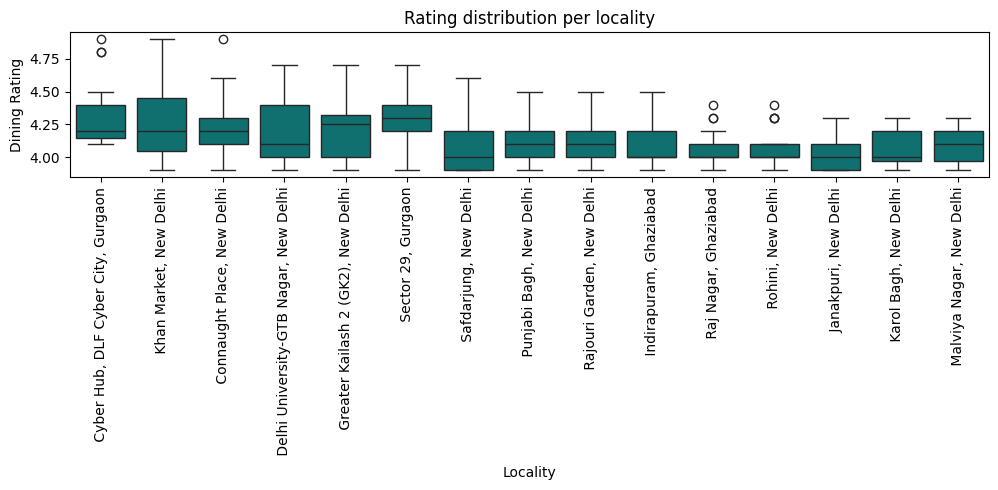

In [18]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_filtered, x='locality', y='dining_rating', color='teal')
plt.title('Rating distribution per locality')
plt.xlabel("Locality")
plt.ylabel("Dining Rating")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Rating distribution is consistently high across all localities (4.0-4.5), with premium areas like Cyber Hub and Khan Market showing more rating variation compared to residential areas like Rohini which maintain consistent quality.

### Which resturant has the biggest gap between dining rating and delivery rating

In [19]:
df_delivery= df[df['delivery_rating']>0]
df_delivery['difference']= df_delivery['dining_rating']- df_delivery['delivery_rating']
top_differences= df_delivery[['restaurant_name', 'difference']].sort_values('difference', ascending= False).head(10)
print(top_differences)

                             restaurant_name  difference
318                      DEL - Roseate House         1.5
21                       Olive Bar & Kitchen         1.5
102                       The Imperial Spice         1.4
807       Unlocked - Bar.Kitchen.Escape Room         1.2
57                Hamoni: Cafe By The Greens         1.2
6              Cocktails & Dreams, Speakeasy         1.1
562  Café Pluck - Pullman New Delhi Aerocity         1.1
63                       Vapour Bar Exchange         1.1
61                           Barbeque Nation         1.1
451                           Fur Ball Story         1.1


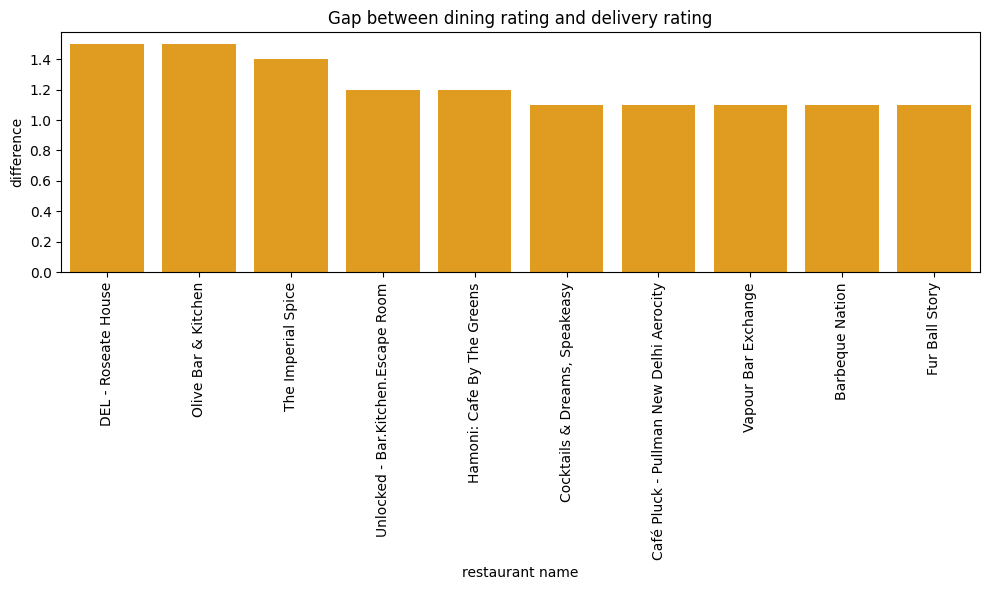

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_differences, x= 'restaurant_name', y='difference', color='orange')
plt.title('Gap between dining rating and delivery rating')
plt.xlabel('restaurant name')
plt.ylabel('difference')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Premium restaurants show the largest gap between dining and delivery ratings, suggesting that fine dining experience heavily depends on ambience and presentation which cannot be replicated through delivery


### Distribution of cost for two per locality

In [22]:
top_locality_cost= df['locality'].value_counts().head(10).index
df_result= df[df['locality'].isin(top_locality)]


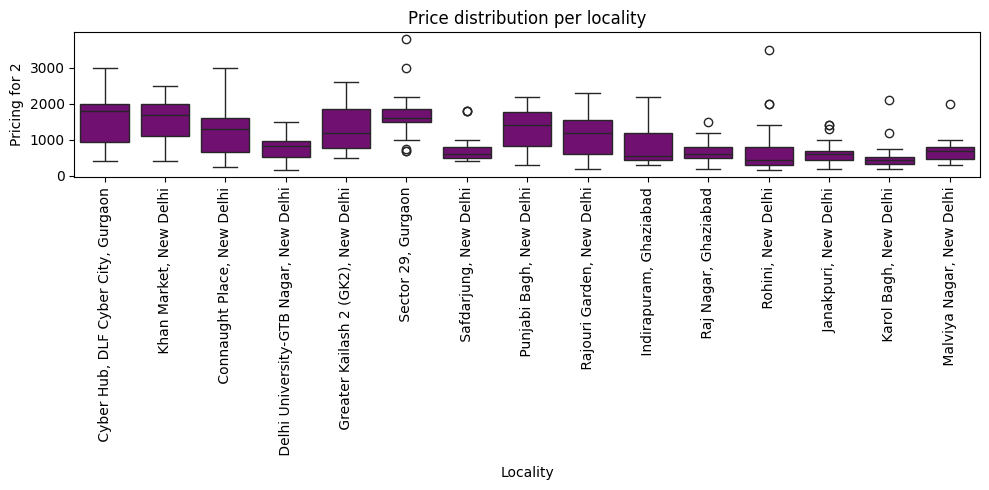

In [23]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_result, x='locality', y='pricing_for_2', color='purple')
plt.title('Price distribution per locality')
plt.xlabel("Locality")
plt.ylabel("Pricing for 2")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Premium commercial areas like Cyber Hub and Khan Market show wide price variation (₹500-₹3000+) while residential areas like Rohini and Karol Bagh consistently offer budget friendly dining (under ₹1000).

### Is there a relation between pricing and dining rating

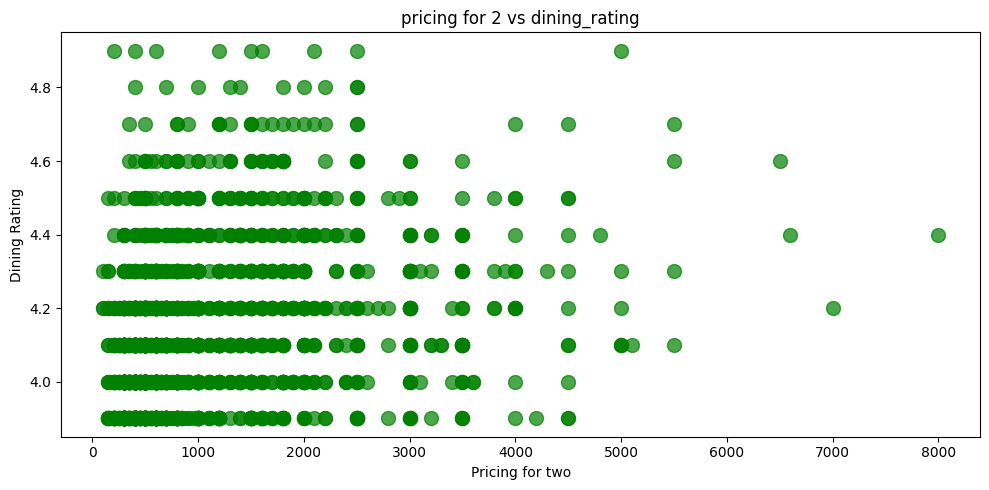

In [24]:
plt.figure(figsize=(10,5))
plt.scatter(df['pricing_for_2'], df['dining_rating'], s=100, c="green", alpha=0.7)
plt.title("pricing for 2 vs dining_rating")
plt.xlabel("Pricing for two")
plt.ylabel("Dining Rating")
plt.tight_layout()
plt.show()

Most restaurants are priced under ₹2000 for two. No strong relationship found between pricing and dining rating — expensive doesn't always mean better.

### Conclusion 
## Conclusion

This analysis of 1,965 restaurants across Delhi NCR reveals several 
key patterns in the dining landscape:

- **Connaught Place** dominates as Delhi's most competitive dining hub 
  with the highest restaurant density
- **Dining experience consistently outperforms delivery** across all 
  localities, with premium restaurants showing the largest gap
- **Price does not guarantee quality** — no strong correlation exists 
  between pricing and ratings, suggesting food quality matters more 
  than price
- **Residential areas like Rohini and Karol Bagh** offer consistently 
  budget friendly dining under ₹1000
- **Hidden gems exist** — several restaurants maintain high ratings 
  despite low review counts, particularly in residential areas

Overall, Delhi NCR's restaurant scene maintains consistently high 
standards (avg rating 4.14) across all price points and localities, 
making it one of India's most vibrant dining cities.